### Snow Model Forcing
#### `3_read_wind_ninja_output.ipynb` 
#### ascii outputs... since the kmz were not useful outside of Google Earth

Notebook contents 
* this is working directly off of `3_create_wind_ninja_input.ipynb` to take a look at the output created there 

created by Cassie Lumbrazo\
last updated: Oct 2025\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

Now that we have .asc output files from WindNinja (velocity, angle, and cloud speed), we can build a clean, time-stacked xarray.Dataset that includes wind speed and wind direction with timestamps inferred from the folder names.

Thus, let's 
1. Walks through all subfolders inside your /output/ directory
2. Extracts the timestamp (e.g., 20241001_0500) from the folder name
3. Reads the .asc files for velocity (_vel.asc) and direction (_ang.asc)
4. Adds them into a single time-stacked xarray.Dataset
5. Saves the dataset as a NetCDF file

In [24]:
import os
import re
import glob
import rasterio
import numpy as np
import xarray as xr
from datetime import datetime

# Base directory where your WindNinja outputs are stored
# base_dir = "/hdd/snow_hydrology/wind_ninja/test4/output/"
base_dir = "/hdd/snow_hydrology/wind_ninja/test5/output/"


# Pattern to extract timestamp from folder name
timestamp_pattern = re.compile(r"windninja_(\d{8})_(\d{4})")

# Collect all subdirectories (each one has a timestamp)
subdirs = sorted([os.path.join(base_dir, d) for d in os.listdir(base_dir)
                  if os.path.isdir(os.path.join(base_dir, d))])

data_list = []

for subdir in subdirs:
    match = timestamp_pattern.search(subdir)
    if not match:
        print(f"Skipping {subdir}: no valid timestamp found.")
        continue

    date_part, time_part = match.groups()
    timestamp = datetime.strptime(date_part + time_part, "%Y%m%d%H%M")

    vel_path = glob.glob(os.path.join(subdir, "*_vel.asc"))
    ang_path = glob.glob(os.path.join(subdir, "*_ang.asc"))

    if not vel_path or not ang_path:
        print(f"Missing vel/ang files in {subdir}, skipping.")
        continue

    # Read the velocity and direction rasters
    with rasterio.open(vel_path[0]) as src_vel:
        vel = src_vel.read(1)
        transform = src_vel.transform
        crs = src_vel.crs
        x_coords = np.arange(vel.shape[1]) * transform.a + transform.c
        y_coords = np.arange(vel.shape[0]) * transform.e + transform.f

    with rasterio.open(ang_path[0]) as src_ang:
        ang = src_ang.read(1)

    # Create a Dataset for this timestamp
    ds = xr.Dataset(
        {
            "wind_speed": (("y", "x"), vel),
            "wind_dir": (("y", "x"), ang),
        },
        coords={
            "x": x_coords,
            "y": y_coords,
            "time": timestamp,
        },
        attrs={"crs": str(crs)}
    )

    data_list.append(ds)

# Combine all timestamps into one Dataset
if data_list:
    ds_all = xr.concat(data_list, dim="time")
    print(ds_all)

    # Save to NetCDF
    output_path = os.path.join(base_dir, "windninja_timeseries.nc")
    ds_all.to_netcdf(output_path)
    print(f"✅ Saved stacked dataset to {output_path}")
else:
    print("⚠️ No valid datasets found.")


<xarray.Dataset> Size: 39MB
Dimensions:     (time: 721, y: 78, x: 87)
Coordinates:
  * x           (x) float64 696B 5.238e+05 5.239e+05 ... 5.323e+05 5.324e+05
  * y           (y) float64 624B 6.463e+06 6.463e+06 ... 6.456e+06 6.455e+06
  * time        (time) datetime64[ns] 6kB 2024-11-01 ... 2024-12-01
Data variables:
    wind_speed  (time, y, x) float32 20MB 2.23 2.34 2.55 2.57 ... 3.78 5.3 6.79
    wind_dir    (time, y, x) float32 20MB 308.0 319.0 328.0 ... 267.0 255.0
Attributes:
    crs:      EPSG:32608
✅ Saved stacked dataset to /hdd/snow_hydrology/wind_ninja/test5/output/windninja_timeseries.nc


### Open the Output NetCDF

That worked, Let's take a look.

In [25]:
ds_all

<xarray.Dataset> Size: 39MB
Dimensions:     (time: 721, y: 78, x: 87)
Coordinates:
  * x           (x) float64 696B 5.238e+05 5.239e+05 ... 5.323e+05 5.324e+05
  * y           (y) float64 624B 6.463e+06 6.463e+06 ... 6.456e+06 6.455e+06
  * time        (time) datetime64[ns] 6kB 2024-11-01 ... 2024-12-01
Data variables:
    wind_speed  (time, y, x) float32 20MB 2.23 2.34 2.55 2.57 ... 3.78 5.3 6.79
    wind_dir    (time, y, x) float32 20MB 308.0 319.0 328.0 ... 267.0 255.0
Attributes:
    crs:      EPSG:32608

In [26]:
# open the output netcdf 
# ds_wn = xr.open_dataset("/hdd/snow_hydrology/wind_ninja/test4/output/windninja_timeseries.nc")
ds_wn = xr.open_dataset("/hdd/snow_hydrology/wind_ninja/test5/output/windninja_timeseries.nc")
ds_wn.rio.write_crs('EPSG:4326', inplace=True)  # the data is in lat/lon
ds_wn

<xarray.Dataset> Size: 39MB
Dimensions:      (time: 721, y: 78, x: 87)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2024-11-01 ... 2024-12-01
  * x            (x) float64 696B 5.238e+05 5.239e+05 ... 5.323e+05 5.324e+05
  * y            (y) float64 624B 6.463e+06 6.463e+06 ... 6.456e+06 6.455e+06
    spatial_ref  int64 8B 0
Data variables:
    wind_speed   (time, y, x) float32 20MB ...
    wind_dir     (time, y, x) float32 20MB ...

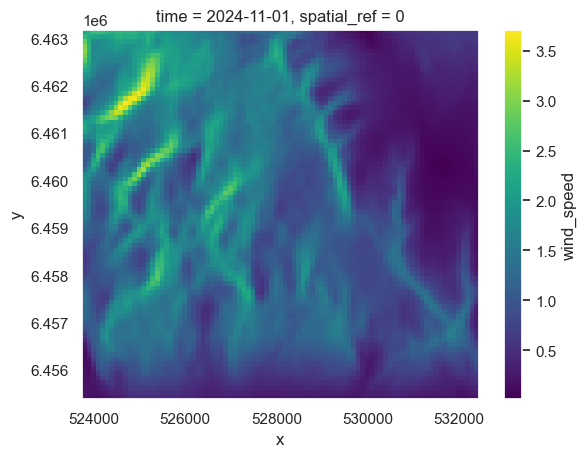

In [27]:
# plot a single timestep 
ds_wn.isel(time=0).wind_speed.plot()

In [28]:
# # Assign latitude and longitude as coordinates for y and x axes
# ds = ds.assign_coords({"y": ds.latitude[:, 0], "x": ds.longitude[0, :]})

# # Now, check the coordinates again to make sure they are assigned properly
# print(ds.coords)

# # Now assign the CRS with EPSG:4326 (assuming the lat/lon are in degrees)
# ds.rio.write_crs("EPSG:4326", inplace=True)

# ds.rio.crs

# Powder Patch Lat/Lon
lat_powderpatch = 58.26200
lon_powderpatch = -134.51700

# select the nearest grid point to the given lat/lon
ds_wn_powderpatch = ds_wn.sel(y=lat_powderpatch, x=lon_powderpatch, method='nearest') 

In [29]:
ds_wn_powderpatch

<xarray.Dataset> Size: 12kB
Dimensions:      (time: 721)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2024-11-01 ... 2024-12-01
    x            float64 8B 5.238e+05
    y            float64 8B 6.455e+06
    spatial_ref  int64 8B 0
Data variables:
    wind_speed   (time) float32 3kB ...
    wind_dir     (time) float32 3kB ...

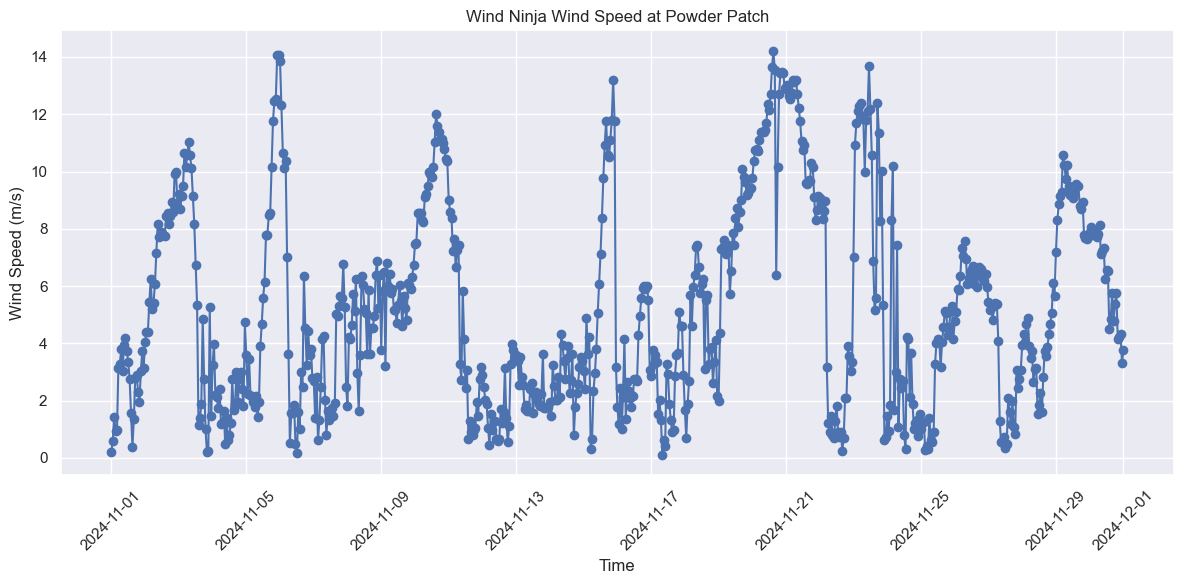

In [30]:
# zoom in the xaxis to see the time series better
plt.figure(figsize=(12, 6))
plt.plot(ds_wn_powderpatch['time'].values, ds_wn_powderpatch['wind_speed'].values, marker='o', linestyle='-', color='b')
plt.title('Wind Ninja Wind Speed at Powder Patch')
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s)')
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()
plt.show()

holy shit it worked. let's go. 

# Now, bring the HRRR data back in.... 
and then we will bring the wind speed from the tower at Powder Patch and compare them all. 

In [22]:
# read this input file 
hrrr_input_file = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_utm_1monthonly.nc"

ds_hrrr = xr.open_dataset(hrrr_input_file)
ds_hrrr.rio.write_crs('EPSG:32608', inplace=True)  # the data is in UTM zone 8N
ds_hrrr

<xarray.Dataset> Size: 5MB
Dimensions:                  (time: 721, y: 20, x: 21)
Coordinates:
    step                     (time) timedelta64[ns] 6kB ...
  * time                     (time) datetime64[ns] 6kB 2024-11-01 ... 2024-12-01
    valid_time               (time) datetime64[ns] 6kB ...
  * x                        (x) float64 168B 5.039e+05 5.069e+05 ... 5.633e+05
  * y                        (y) float64 160B 6.495e+06 6.492e+06 ... 6.439e+06
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Data variables:
    u10                      (time, y, x) float32 1MB ...
    v10                      (time, y, x) float32 1MB ...
    wind_speed               (time, y, x) float32 1MB ...
    wind_direction           (time, y, x) float32 1MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

Select the Powder Patch Gridcell

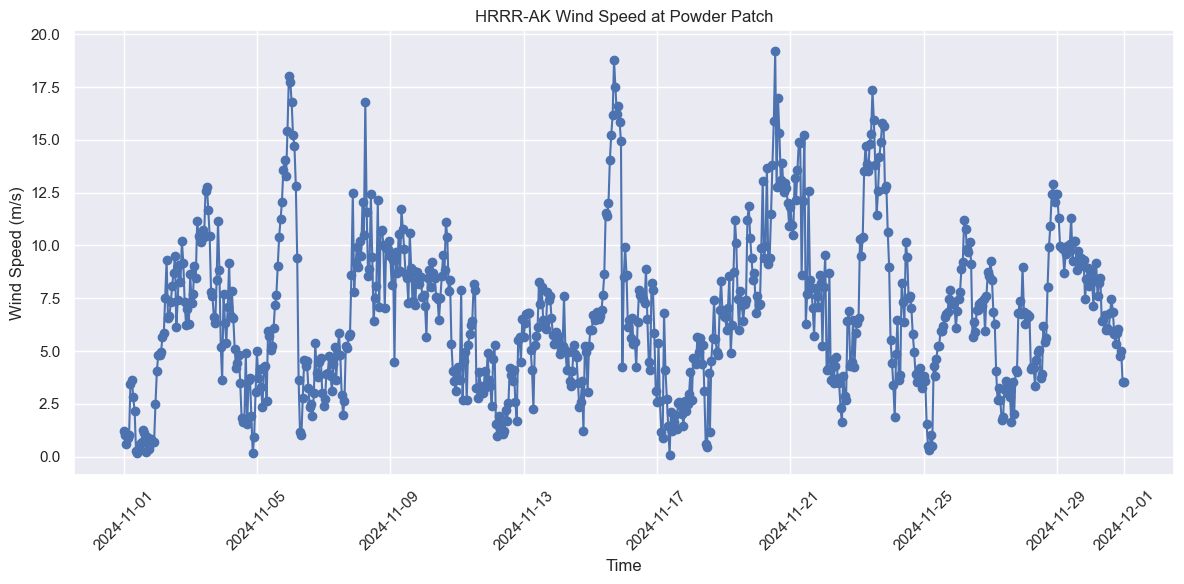

In [23]:
# Powder Patch Lat/Lon
lat_powderpatch = 58.26200
lon_powderpatch = -134.51700

# select the nearest grid point to the given lat/lon
ds_hrrr_pp = ds_hrrr.sel(y=lat_powderpatch, x=lon_powderpatch, method='nearest') 

# and plot the timeseries 
plt.figure(figsize=(12, 6))
plt.plot(ds_hrrr_pp['time'].values, ds_hrrr_pp['wind_speed'].values, marker='o', linestyle='-', color='b')
plt.title('HRRR-AK Wind Speed at Powder Patch')
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s)')
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()
plt.show()